## Exploratory Data Analysis on S&P 500 Subset

This section provides an overview and basic statistics for the subset of S&P 500 companies (top 3 by weight in each sector).

In [53]:
import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])


In [54]:
# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)


In [55]:
sp500_subset.head()


,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight
0,2020-11-23,84.081802,84.559074,83.168406,83.884313,7541500,ABBV,AbbVie,Health Care,0.007
1,2020-11-24,85.546516,86.254193,84.410945,84.657805,9322200,ABBV,AbbVie,Health Care,0.007
2,2020-11-25,85.744026,85.957977,85.077496,85.431334,6368100,ABBV,AbbVie,Health Care,0.007
3,2020-11-27,86.311798,87.060621,85.826302,86.385860,4418800,ABBV,AbbVie,Health Care,0.007
4,2020-11-30,86.056725,86.747940,85.291446,86.501080,20726500,ABBV,AbbVie,Health Care,0.007


In [56]:
sectors_wgts.head()

,Symbol,Security,Sector,Weight
0,MMM,3M,Industrials,0.0015
1,AOS,A. O. Smith,Industrials,0.0002
2,ABT,Abbott Laboratories,Health Care,0.0037
3,ABBV,AbbVie,Health Care,0.0070
4,ACN,Accenture,Information Technology,0.0026


In [57]:
# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max:", sp500_subset["Date"].max())
print("\nNumber of symbols in price subset:", sp500_subset["Symbol"].nunique())
print("\nMissing values:")
print(sp500_subset.isna().sum())

Price data shape: (41125, 10)

Columns in price data: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Security',
       'Sector', 'Weight'],
      dtype='object')

Date range:
Min: 2020-11-23 00:00:00 | Max: 2025-11-20 00:00:00

Number of symbols in price subset: 33

Missing values:
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [58]:
# Weights and Sectors Data

print("Weight data shape:", sectors_wgts.shape)
print("\nColumns in weight data:", sectors_wgts.columns)
print("Number of sectors in weight dataset:", sectors_wgts["Sector"].nunique())
print("\nMissing values:")
print(sectors_wgts.isna().sum())

Weight data shape: (503, 4)

Columns in weight data: Index(['Symbol', 'Security', 'Sector', 'Weight'], dtype='object')
Number of sectors in weight dataset: 11

Missing values:
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [59]:
print(sp500_subset.head())
print(sp500_subset.isna().sum())

missing = sp500_subset[sp500_subset["Weight"].isna()]["Symbol"].unique()
print("Symbols missing weights:", missing)

        Date      Close       High        Low       Open    Volume Symbol  \
0 2020-11-23  84.081802  84.559074  83.168406  83.884313   7541500   ABBV   
1 2020-11-24  85.546516  86.254193  84.410945  84.657805   9322200   ABBV   
2 2020-11-25  85.744026  85.957977  85.077496  85.431334   6368100   ABBV   
3 2020-11-27  86.311798  87.060621  85.826302  86.385860   4418800   ABBV   
4 2020-11-30  86.056725  86.747940  85.291446  86.501080  20726500   ABBV   

  Security       Sector  Weight  
0   AbbVie  Health Care   0.007  
1   AbbVie  Health Care   0.007  
2   AbbVie  Health Care   0.007  
3   AbbVie  Health Care   0.007  
4   AbbVie  Health Care   0.007  
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64
Symbols missing weights: []


In [68]:
# Total sum of weights from S&P 500 subset

unique_securities = (
    sp500_subset[["Symbol", "Security", "Sector", "Weight"]]
    .drop_duplicates("Symbol")
    .sort_values("Weight", ascending=False)
)

sum_weights = unique_securities["Weight"].sum()
print(f"Total sum of weights in subset: {sum_weights*100:.2f}%")

Total sum of weights in subset: 49.96%


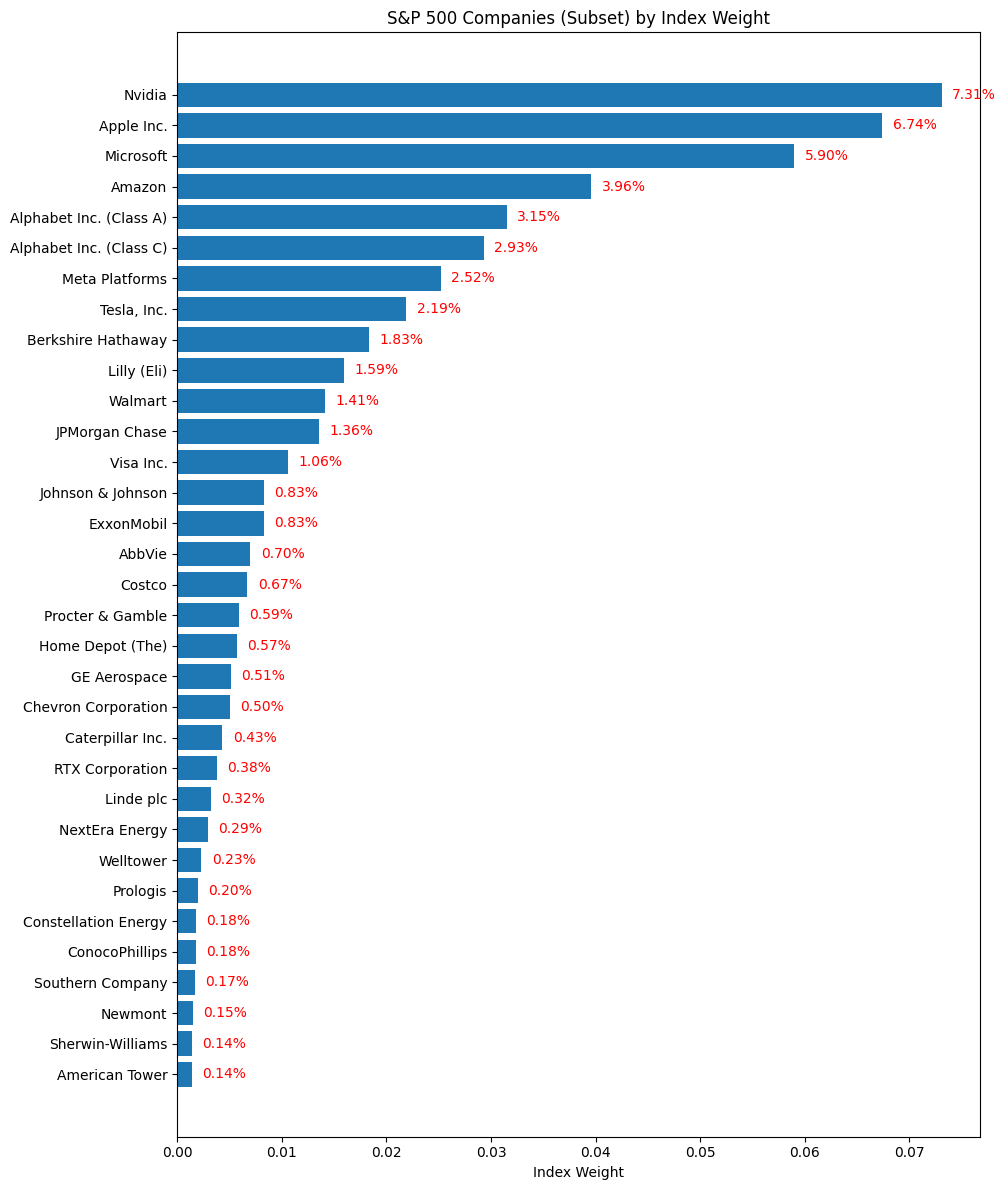

In [69]:
# Plot all S&P 500 Subset companies by weight with % labels

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
bars = plt.barh(
    unique_securities["Security"],
    unique_securities["Weight"]
)
plt.gca().invert_yaxis()
plt.title("S&P 500 Companies (Subset) by Index Weight")
plt.xlabel("Index Weight")
plt.tight_layout()

# Add % labels in red at the end of each bar
for bar, weight in zip(bars, unique_securities["Weight"]):
    plt.text(
        bar.get_width() + 0.001,  # Slightly after the end of the bar
        bar.get_y() + bar.get_height() / 2,
        f"{weight*100:.2f}%",
        va='center',
        ha='left',
        color='red',
        fontsize=10
    )

plt.show()


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Number of sectors to randomly include
X = 5   # <-- change this number to pick 5 sectors, or 3, or 8, etc.

# Get unique sectors
all_sectors = sorted(sp500_subset["Sector"].unique())

# Randomly pick X sectors
chosen_sectors = np.random.choice(all_sectors, size=X, replace=False)
print("Randomly selected sectors:", chosen_sectors)

# Filter to only those sectors
filtered = sp500_subset[sp500_subset["Sector"].isin(chosen_sectors)]

# Pick 1 random company for each chosen sector
unique_sec = filtered[["Symbol", "Sector"]].drop_duplicates()

selected_symbols = (
    unique_sec
    .groupby("Sector")["Symbol"]
    .apply(lambda x: np.random.choice(list(x), 1)[0])
)

print("\nRandomly selected companies from these sectors:")
print(selected_symbols)


Randomly selected sectors: ['Health Care' 'Communication Services' 'Real Estate' 'Utilities'
 'Consumer Staples']

Randomly selected companies from these sectors:
Sector
Communication Services    GOOGL
Consumer Staples            WMT
Health Care                 JNJ
Real Estate                 AMT
Utilities                   NEE
Name: Symbol, dtype: object


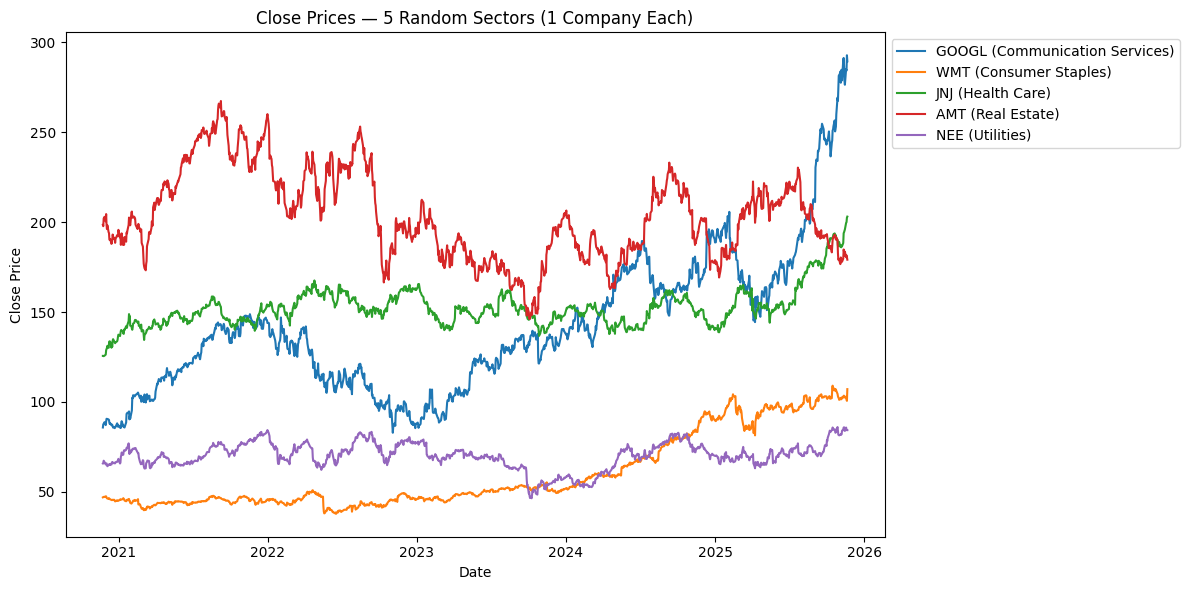

In [76]:
# Plot Close prices 

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Close"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Close Prices — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



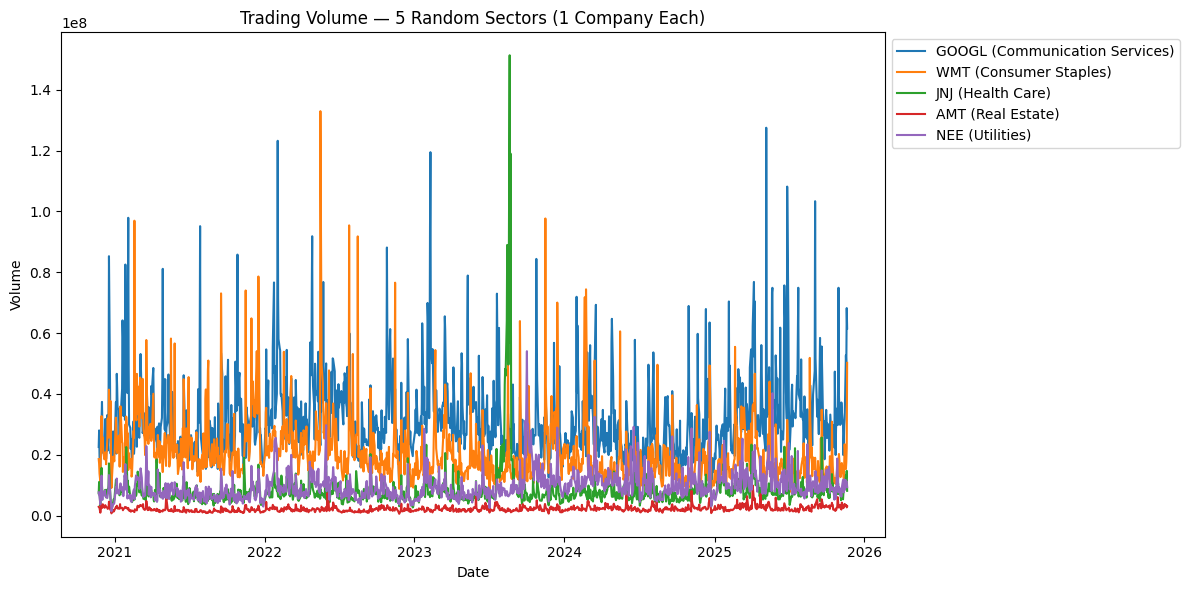

In [77]:
# Plot Volume

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Volume"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Trading Volume — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



In [ ]:
# Cal Stock Returns

import numpy as np

sp500_subset2 = sp500_subset.sort_values(["Symbol", "Date"]).copy()

sp500_subset2["Return"] = (
    sp500_subset2.groupby("Symbol")["Close"]
    .transform(lambda x: x.pct_change())
)

sp500_subset2["LogReturn"] = np.log1p(sp500_subset2["Return"])


sp500_subset2[["Date", "Symbol", "Close", "Return", "LogReturn"]].head(10)

,Date,Symbol,Close,Return,LogReturn
6275,2020-11-23,AAPL,110.827545,NaN,NaN
6276,2020-11-24,AAPL,112.112503,0.011594,0.011528
6277,2020-11-25,AAPL,112.949669,0.007467,0.007439
6278,2020-11-27,AAPL,113.494804,0.004826,0.004815
6279,2020-11-30,AAPL,115.889488,0.021100,0.020880
6280,2020-12-01,AAPL,119.462082,0.030828,0.030362
6281,2020-12-02,AAPL,119.812508,0.002933,0.002929
6282,2020-12-03,AAPL,119.676231,-0.001137,-0.001138
6283,2020-12-04,AAPL,119.004547,-0.005613,-0.005628
6284,2020-12-07,AAPL,120.464737,0.012270,0.012195


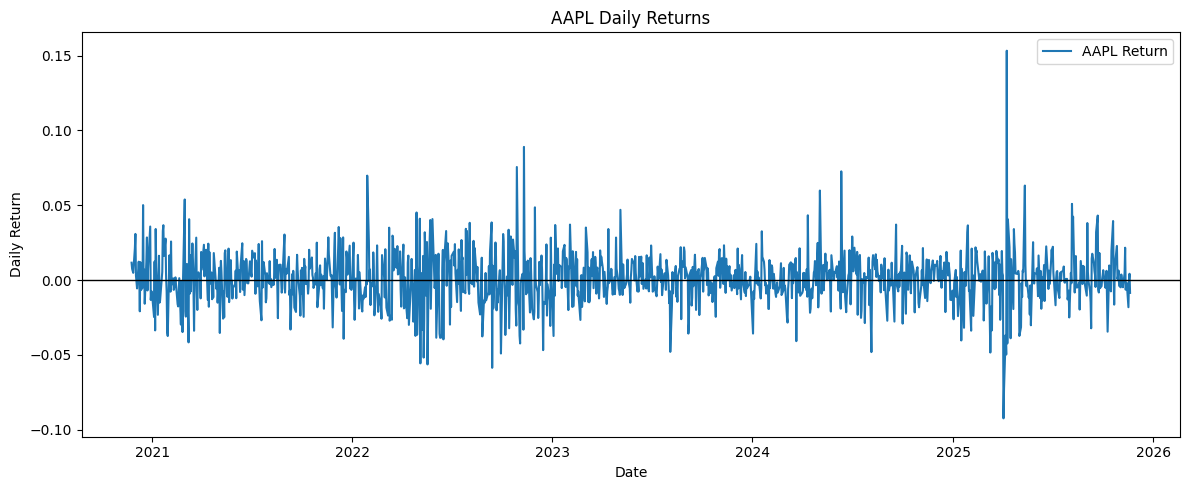

In [91]:
import matplotlib.pyplot as plt

# Filter AAPL
aapl = sp500_subset2[sp500_subset2["Symbol"] == "AAPL"]

# Reset index (optional but avoids weird notebook behavior)
aapl = aapl.sort_values("Date").reset_index(drop=True)

plt.figure(figsize=(12,5))
plt.plot(aapl["Date"], aapl["Return"], label="AAPL Return")
plt.axhline(0, color="black", linewidth=1)
plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()


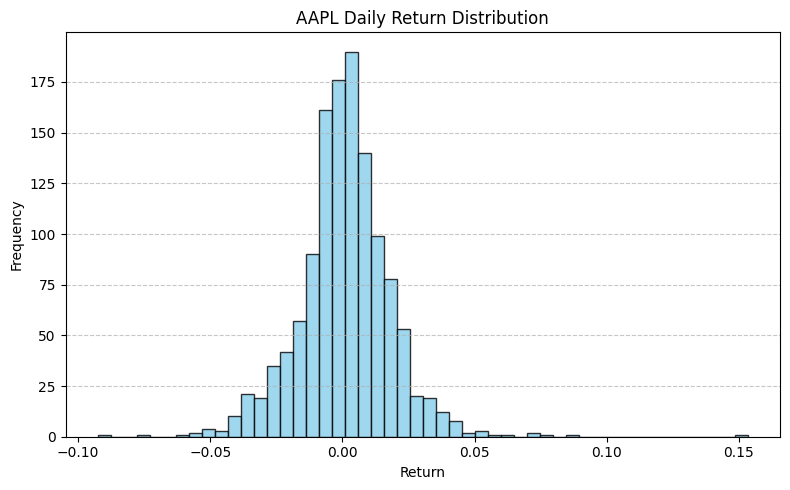

In [92]:
# Histogram for AAPL Daily Returns

plt.figure(figsize=(8, 5))
returns = aapl["Return"].dropna()
plt.hist(returns, bins=50, edgecolor="black", color="skyblue", alpha=0.8)
plt.title("AAPL Daily Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
